# Log Anomaly Detection (BGL Dataset): LLM Few-Shot + CoT Baseline

**Experiment:** E02 — Prompt-only LLM anomaly detection. No retrieval, no embeddings, no training.  
**Dataset:** BGL  
**Inference model:** `llama-3.3-70b-versatile` via Groq API  
**Prompting strategy:** Few-shot Chain-of-Thought (CoT)  
**Evaluation model:** `qwen/qwen3-32b` via Groq API (LLM-as-judge)  

In [1]:
# =============================================================================
# CELL 1 — PACKAGE INSTALLATION
# =============================================================================

import subprocess
import sys


def install_packages(packages):
    for pkg in packages:
        print(f"Installing: {pkg}")
        result = subprocess.run(
            [sys.executable, "-m", "pip", "install", pkg, "-q"],
            capture_output=True,
            text=True,
        )
        if result.returncode != 0:
            print(f"  WARNING: may have failed — {result.stderr[:200]}")
        else:
            print("  OK")


install_packages([
    "pandas",
    "numpy",
    "scikit-learn",
    "matplotlib",
    "seaborn",
    "groq",
    "tqdm",
])
print("\nAll packages ready.")

Installing: pandas
  OK
Installing: numpy
  OK
Installing: scikit-learn
  OK
Installing: matplotlib
  OK
Installing: seaborn
  OK
Installing: groq
  OK
Installing: tqdm
  OK

All packages ready.


  Dataset              : BGL
  LLM model            : llama-3.1-8b-instant
  Eval model           : qwen/qwen3-32b
  Few-shot normal      : 5  (balanced)
  Few-shot anomaly     : 5  (balanced, excluded from test)
  Test normal cap      : 200
  Test anomaly cap     : 15
  Target anomaly rate  : 7.0%  (BGL real-world ~7%)
  Primary Groq keys    : 5  | Fallback keys: 5
Loading dataset: BGL
  Loading BGL structured log ...
    Rows: 2000, Templates: 120

  Total samples : 2000
  Normal        : 1857  (92.8%)
  Anomalous     : 143  (7.1%)

  Sample log_text:
    [KERNEL] [INFO] instruction cache parity error corrected | Template: instruction cache parity error corrected

Creating few-shot pools and test split ...

  Few-shot normal pool  : 5 (used in prompt)
  Few-shot anomaly pool : 5 (excluded from test; prompt uses handcrafted examples)

  Test set              : 215 total
    Normal              : 200  (93.0%)
    Anomalous           : 15  (7.0%)

System prompt length : 9723 characters


LLM Inference:   8%|▊         | 18/215 [00:25<10:46,  3.28s/it]

  [rate-limit] Worker rotated to fallback key (attempt 1/9)


LLM Inference: 100%|██████████| 215/215 [14:31<00:00,  4.05s/it]



  Inference complete.  Parse errors: 0 / 215

  LATENCY & GENERATION TIME  [BGL]  (n=215)
  Metric                          Latency (ms)   Generation (ms)    Total (ms)
--------------------------------------------------------------------------------
  Mean                                 19169.3             336.2       19505.5
  Median (p50)                         22262.0             149.7       22578.9
  p95                                  24757.0            1381.5       25094.8
  p99                                  27659.6            1563.4       27939.8
  Min                                    279.7               1.9         281.6
  Max                                  27770.7            1748.3       28191.0

  EVALUATION  --  LLM Few-Shot + CoT  [BGL]
  Test set size          : 215
    Normal   (neg)       : 200  (93.0%)
    Anomalous (pos)      : 15  (7.0%)
----------------------------------------------------------------
  TP  : 15   TN  : 170   FP  : 30   FN  : 0
------------

LLM-as-Judge: 100%|██████████| 15/15 [08:03<00:00, 32.24s/it]



  LLM-AS-JUDGE METRICS  [BGL]  (n=15)
  Faithfulness                   : 0.8200
  Answer Relevance               : 0.8733
  Completeness                   : 1.0000
  Role Appropriateness (SRE)     : 0.9200
  Role Appropriateness (DevOps)  : 1.0000

Generating visualisations ...


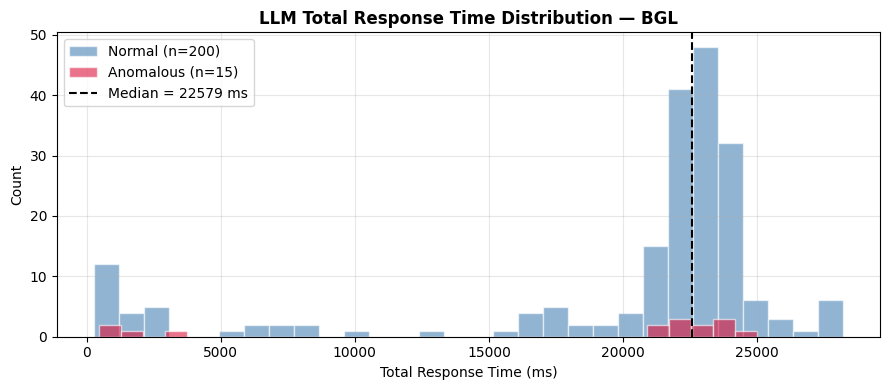

  Saved: bgl_llm_response_time_dist.png


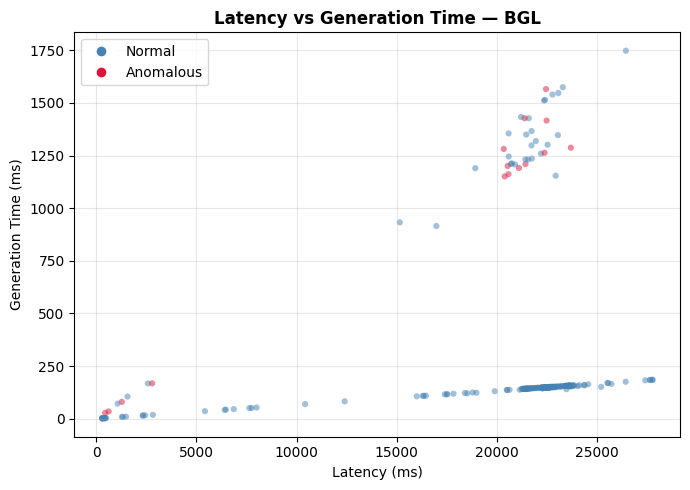

  Saved: bgl_llm_latency_scatter.png


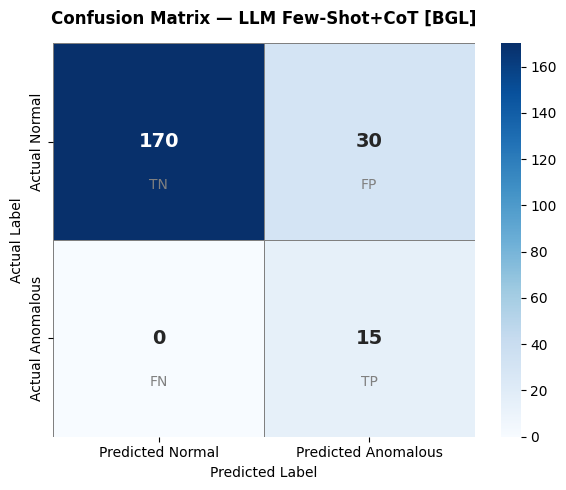

  Saved: bgl_llm_confusion_matrix.png


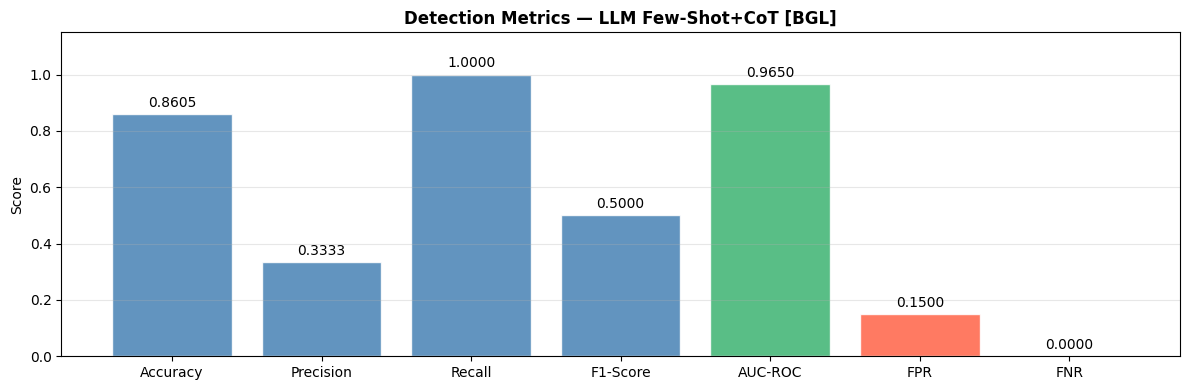

  Saved: bgl_llm_detection_metrics.png


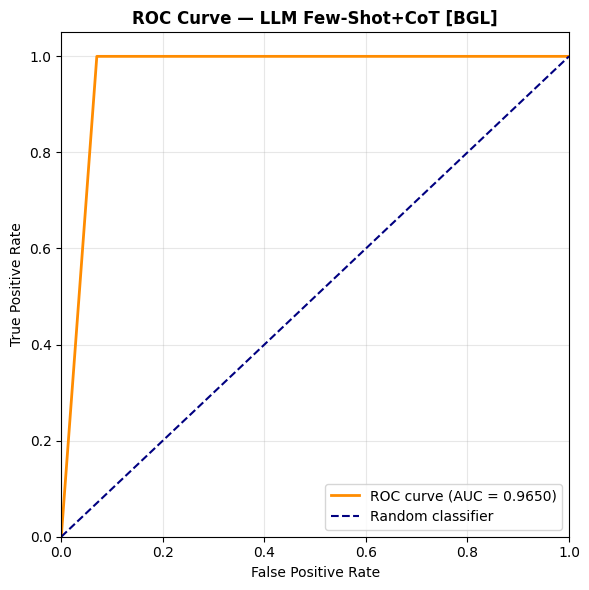

  Saved: bgl_llm_roc_curve.png


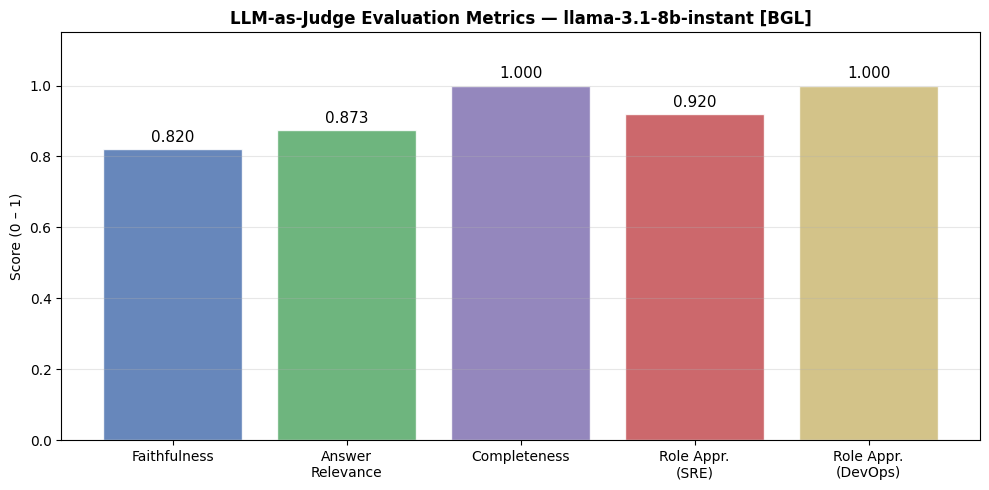

  Saved: bgl_llm_llm_eval_metrics.png


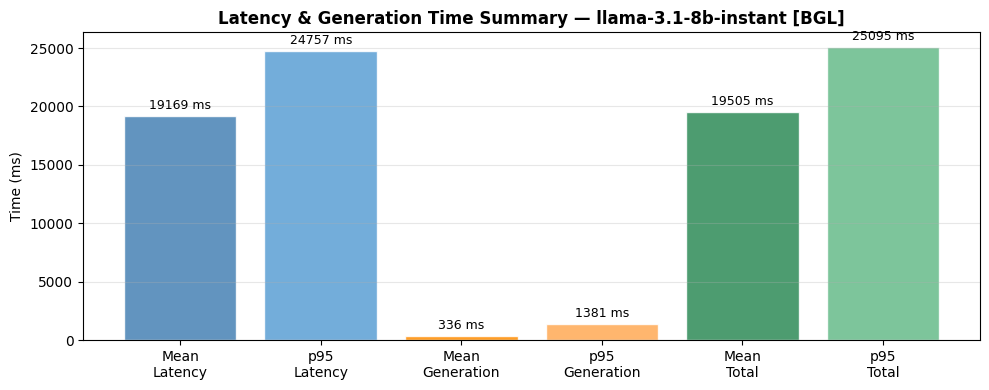

  Saved: bgl_llm_latency_summary.png


In [4]:
# =============================================================================
# CELL 2 — IMPORTS, CONFIGURATION, DATA LOADING, FEW-SHOT PROMPTING,
#           LLM INFERENCE, STANDARD METRICS, LATENCY PROFILING,
#           LLM-AS-JUDGE EVALUATION, AND VISUALISATION
# =============================================================================

# -- Standard library imports -------------------------------------------------
import json
import os
import re
import sys
import threading
import time
import warnings
from typing import Any, Dict, List, Optional, Tuple

# -- Third-party imports ------------------------------------------------------
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from groq import Groq
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor, as_completed

warnings.filterwarnings("ignore")

# -- Shared prompt imports from src/Prompts/ ----------------------------------
_PROMPTS_DIR = os.path.abspath(os.path.join(os.getcwd(), "..", "Prompts"))
if _PROMPTS_DIR not in sys.path:
    sys.path.insert(0, _PROMPTS_DIR)

from detection_prompts import BGL_CONFIG, build_llm_system_prompt, build_llm_user_prompt
from eval_prompts import (
    JUDGE_SYSTEM_PROMPT,
    build_faithfulness_prompt,
    build_answer_relevance_prompt,
    build_completeness_prompt_llm,
    build_sre_appropriateness_prompt,
    build_devops_appropriateness_prompt,
)

# =============================================================================
# SECTION 1 — CONFIGURATION
# =============================================================================

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# -- Dataset ------------------------------------------------------------------
DATASET = "BGL"

# -- Groq API keys — groq_key_1.txt…groq_key_5.txt (primary, one per worker)
#                    groq_key_6.txt…groq_key_10.txt (fallback on rate-limit) -
def _load_groq_key(n: int) -> Optional[str]:
    p = os.path.join(os.path.dirname(os.getcwd()), "Keys", f"groq_key_{n}.txt")
    try:
        with open(p) as _f:
            return _f.read().strip()
    except FileNotFoundError:
        return None

_ALL_PRIMARY  = [k for k in [_load_groq_key(i) for i in range(1, 6)]  if k]
_ALL_FALLBACK = [k for k in [_load_groq_key(i) for i in range(6, 11)] if k]

if not _ALL_PRIMARY:
    raise FileNotFoundError(
        "No primary Groq keys found. "
        "Expected src/Keys/groq_key_1.txt … groq_key_5.txt"
    )

GROQ_API_KEY = _ALL_PRIMARY[0]   # kept for any direct references

# -- Model names (configurable) -----------------------------------------------
LLM_MODEL  = "llama-3.1-8b-instant"  # anomaly detection / inference model
EVAL_MODEL = "qwen/qwen3-32b"           # LLM-as-judge evaluation model

# -- Few-shot configuration ---------------------------------------------------
# Kept balanced (equal normal/anomalous) regardless of dataset imbalance.
# Few-shot examples teach reasoning patterns for both classes equally;
# skewing toward the majority class biases predictions toward Normal.
N_FEW_SHOT_NORMAL    = 5
N_FEW_SHOT_ANOMALOUS = 5


# Independent variables, decoupled from few-shot pool sizes.
TEST_NORMAL_CAP  = 200
TEST_ANOMALY_CAP = 15

# -- Groq API call configuration ----------------------------------------------
MAX_RETRIES     = 3
RETRY_DELAY_S   = 5    # seconds between retries on transient errors
REQUEST_DELAY_S = 0.5  # seconds between successive calls (rate-limit buffer)
LLM_MAX_TOKENS  = 500  # increased: anomalous responses carry 3 explanation fields
LLM_TEMPERATURE = 0.0
# qwen3-32b uses a thinking-mode prefix (<think>...</think>) before the JSON
# response — 1024 tokens gives enough budget for the thinking trace + JSON output.
EVAL_MAX_TOKENS = 1024

# -- Dataset paths ------------------------------------------------------------
DATASET_CONFIGS: Dict[str, Dict] = {
    "BGL": {
        "structured_log_path": "../../Datasets/BGL/Sample/BGL_2k.log_structured.csv",
        "templates_path":      "../../Datasets/BGL/Sample/BGL_2k.log_templates.csv",
        "label_col":     "Label",
        "normal_value":  "-",
        "event_id_col":  "EventId",
        "component_col": "Component",
        "level_col":     "Level",
        "content_col":   "Content",
        "template_col":  "EventTemplate",
        "normal_sample_cap":  None,
        "anomaly_type_col":   None,
        "anomaly_n_per_type": None,
    },
    "HDFS": {
        "traces_path":    "../../Datasets/HDFS/Full_HDFS_v1/preprocessed/Event_traces.csv",
        "templates_path": "../../Datasets/HDFS/Full_HDFS_v1/preprocessed/HDFS.log_templates.csv",
        "label_col":    "Label",
        "normal_value": "Success",
        "features_col": "Features",
        "normal_sample_cap":  10000,
        "anomaly_type_col":   "Type",
        "anomaly_n_per_type": 20,
    },
}

print(f"  Dataset              : {DATASET}")
print(f"  LLM model            : {LLM_MODEL}")
print(f"  Eval model           : {EVAL_MODEL}")
print(f"  Few-shot normal      : {N_FEW_SHOT_NORMAL}  (balanced)")
print(f"  Few-shot anomaly     : {N_FEW_SHOT_ANOMALOUS}  (balanced, excluded from test)")
print(f"  Test normal cap      : {TEST_NORMAL_CAP}")
print(f"  Test anomaly cap     : {TEST_ANOMALY_CAP}")
print(
    f"  Target anomaly rate  : "
    f"{TEST_ANOMALY_CAP / (TEST_NORMAL_CAP + TEST_ANOMALY_CAP) * 100:.1f}%"
    f"  (BGL real-world ~7%)"
)
print(f"  Primary Groq keys    : {len(_ALL_PRIMARY)}  | Fallback keys: {len(_ALL_FALLBACK)}")

# =============================================================================
# SECTION 2 — DATA LOADING (DATASET-AGNOSTIC)
# =============================================================================

def _apply_sampling(
    df: pd.DataFrame,
    config: Dict,
    random_seed: int = 42,
) -> pd.DataFrame:
    """Apply per-dataset sampling caps.  No-op when all caps are None."""
    normal_cap    = config.get("normal_sample_cap")
    anom_type_col = config.get("anomaly_type_col")
    n_per_type    = config.get("anomaly_n_per_type")
    anom_cap      = config.get("anomaly_sample_cap")

    df_n = df[df["is_normal"]].copy()
    df_a = df[~df["is_normal"]].copy()

    if normal_cap is not None and len(df_n) > normal_cap:
        df_n = df_n.sample(n=normal_cap, random_state=random_seed)

    if anom_type_col and n_per_type:
        parts = [
            grp.sample(n=min(n_per_type, len(grp)), random_state=random_seed)
            for _, grp in df_a.groupby(anom_type_col)
            if len(grp) > 0
        ]
        df_a = pd.concat(parts) if parts else df_a
    elif anom_cap is not None and len(df_a) > anom_cap:
        df_a = df_a.sample(n=anom_cap, random_state=random_seed)

    return pd.concat([df_n, df_a], ignore_index=True)


def build_bgl_log_text(row: pd.Series, config: Dict) -> str:
    component = str(row.get(config["component_col"], "")).strip()
    level     = str(row.get(config["level_col"],     "")).strip()
    content   = str(row.get(config["content_col"],   "")).strip()
    template  = str(row.get(config["template_col"],  "")).strip()
    return f"[{component}] [{level}] {content} | Template: {template}"


def _clean_template(text: str) -> str:
    cleaned = re.sub(r'\[\*\]', '', text)
    return re.sub(r'\s+', ' ', cleaned).strip()


def build_hdfs_log_text(
    row: pd.Series,
    config: Dict,
    template_lookup: Dict,
) -> str:
    features_str = str(row.get(config["features_col"], "[]"))
    event_ids    = re.findall(r'E\d+', features_str)
    seen, unique_templates = set(), []
    for eid in event_ids:
        if eid not in seen:
            seen.add(eid)
            tmpl = template_lookup.get(eid, eid)
            unique_templates.append(_clean_template(tmpl))
    return "HDFS Block Trace | " + " -> ".join(unique_templates)


def load_bgl_data(config: Dict) -> pd.DataFrame:
    print("  Loading BGL structured log ...")
    df_logs      = pd.read_csv(config["structured_log_path"])
    df_templates = pd.read_csv(config["templates_path"])
    print(f"    Rows: {len(df_logs)}, Templates: {len(df_templates)}")
    df = df_logs.merge(
        df_templates, on=config["event_id_col"], how="left", suffixes=("", "_tmpl"),
    )
    df["is_normal"]    = df[config["label_col"]] == config["normal_value"]
    df["binary_label"] = (~df["is_normal"]).astype(int)
    df = _apply_sampling(df, config)
    df["log_text"] = df.apply(lambda row: build_bgl_log_text(row, config), axis=1)
    return df


def load_hdfs_data(config: Dict) -> pd.DataFrame:
    print("  Loading HDFS block traces ...")
    df_traces    = pd.read_csv(config["traces_path"])
    df_templates = pd.read_csv(config["templates_path"])
    print(f"    Block traces: {len(df_traces)}, Templates: {len(df_templates)}")
    template_lookup = dict(zip(df_templates["EventId"], df_templates["EventTemplate"]))
    df_traces["is_normal"]    = df_traces[config["label_col"]] == config["normal_value"]
    df_traces["binary_label"] = (~df_traces["is_normal"]).astype(int)
    df_traces = _apply_sampling(df_traces, config)
    df_traces["log_text"] = df_traces.apply(
        lambda row: build_hdfs_log_text(row, config, template_lookup), axis=1
    )
    return df_traces


def load_data(dataset_name: str, configs: Dict) -> pd.DataFrame:
    if dataset_name not in configs:
        raise ValueError(f"Unknown dataset '{dataset_name}'. Available: {list(configs.keys())}")
    if dataset_name == "BGL":
        return load_bgl_data(configs[dataset_name])
    elif dataset_name == "HDFS":
        return load_hdfs_data(configs[dataset_name])


print(f"Loading dataset: {DATASET}")
df = load_data(DATASET, DATASET_CONFIGS)

n_normal    = int(df["is_normal"].sum())
n_anomalous = int((~df["is_normal"]).sum())
print(f"\n  Total samples : {len(df)}")
print(f"  Normal        : {n_normal}  ({n_normal / len(df) * 100:.1f}%)")
print(f"  Anomalous     : {n_anomalous}  ({n_anomalous / len(df) * 100:.1f}%)")
print(f"\n  Sample log_text:\n    {df['log_text'].iloc[0]}")

# =============================================================================
# SECTION 3 — DATA SPLIT: FEW-SHOT POOLS + TEST SET
#
# No train/val split — this is prompt-only LLM inference; no model is trained
# or validated.  The split serves two purposes only:
#   1. Carve few-shot examples (excluded from test to prevent leakage).
#   2. Build a test set with class counts that reflect real-world BGL imbalance.
#
# All pools are non-overlapping and drawn from independently shuffled data:
#   few_shot_normal_df : N_FEW_SHOT_NORMAL  samples — balanced, used in prompt
#   few_shot_anom_df   : N_FEW_SHOT_ANOMALOUS samples — excluded from test only
#                        (prompt uses handcrafted examples — see Section 4)
#   test_df            : TEST_NORMAL_CAP + TEST_ANOMALY_CAP samples
# =============================================================================

def create_splits(
    df: pd.DataFrame,
    n_few_shot_normal: int,
    n_few_shot_anomalous: int,
    test_normal_cap: int,
    test_anomaly_cap: int,
    random_seed: int = 42,
) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """Return (few_shot_normal_df, few_shot_anom_df, test_df).

    Few-shot pools and test set are fully disjoint.
    Test class counts are independently controlled via explicit caps.
    """
    df_normal = (
        df[df["is_normal"]]
        .sample(frac=1, random_state=random_seed)
        .reset_index(drop=True)
    )
    df_anomalous = (
        df[~df["is_normal"]]
        .sample(frac=1, random_state=random_seed)
        .reset_index(drop=True)
    )

    # Few-shot normals — carved from head of shuffled normals
    n_fs_norm        = min(n_few_shot_normal, len(df_normal))
    few_shot_norm_df = df_normal.iloc[:n_fs_norm].reset_index(drop=True)
    remaining_normal = df_normal.iloc[n_fs_norm:].reset_index(drop=True)

    # Few-shot anomalies — carved before test anomalies to prevent leakage
    n_fs_anom        = min(n_few_shot_anomalous, len(df_anomalous))
    few_shot_anom_df = df_anomalous.iloc[:n_fs_anom].reset_index(drop=True)
    remaining_anom   = df_anomalous.iloc[n_fs_anom:].reset_index(drop=True)

    # Test set with explicit, independent class caps
    n_test_norm = min(test_normal_cap,  len(remaining_normal))
    n_test_anom = min(test_anomaly_cap, len(remaining_anom))

    if n_test_anom < test_anomaly_cap:
        print(
            f"  WARNING: only {n_test_anom} anomalies available for test "
            f"(requested {test_anomaly_cap}). "
            "Reduce N_FEW_SHOT_ANOMALOUS or TEST_ANOMALY_CAP."
        )

    test_df = (
        pd.concat(
            [remaining_normal.iloc[:n_test_norm], remaining_anom.iloc[:n_test_anom]],
            ignore_index=True,
        )
        .sample(frac=1, random_state=random_seed)
        .reset_index(drop=True)
    )
    return few_shot_norm_df, few_shot_anom_df, test_df


print("\nCreating few-shot pools and test split ...")
few_shot_normal_df, few_shot_anom_df, test_df = create_splits(
    df,
    n_few_shot_normal=N_FEW_SHOT_NORMAL,
    n_few_shot_anomalous=N_FEW_SHOT_ANOMALOUS,
    test_normal_cap=TEST_NORMAL_CAP,
    test_anomaly_cap=TEST_ANOMALY_CAP,
    random_seed=RANDOM_SEED,
)

n_test_normal    = int(test_df["is_normal"].sum())
n_test_anomalous = int((~test_df["is_normal"]).sum())

print(f"\n  Few-shot normal pool  : {len(few_shot_normal_df)} (used in prompt)")
print(f"  Few-shot anomaly pool : {len(few_shot_anom_df)} (excluded from test; prompt uses handcrafted examples)")
print(f"\n  Test set              : {len(test_df)} total")
print(f"    Normal              : {n_test_normal}  ({n_test_normal / len(test_df) * 100:.1f}%)")
print(f"    Anomalous           : {n_test_anomalous}  ({n_test_anomalous / len(test_df) * 100:.1f}%)")

# =============================================================================
# SECTION 4 — PROMPT CONSTRUCTION (FEW-SHOT + CHAIN-OF-THOUGHT)
#
# Prompts are defined in src/Prompts/detection_prompts.py and imported above.
# build_llm_system_prompt uses real BGL normal entries + 5 handcrafted anomalous
# examples (internally consistent, fault types distinct from test anomalies).
# build_llm_user_prompt wraps a single log entry for the user turn.
# =============================================================================

SYSTEM_PROMPT = build_llm_system_prompt(few_shot_normal_df, few_shot_anom_df, BGL_CONFIG)
print(f"\nSystem prompt length : {len(SYSTEM_PROMPT)} characters")

# =============================================================================
# SECTION 5 — GROQ CLIENT AND INFERENCE HELPERS
# =============================================================================

# --- Parallel key pool: thread-local primary key + shared fallback pool -----
N_PARALLEL_WORKERS = min(5, len(_ALL_PRIMARY))

_fallback_lock = threading.Lock()
_fallback_pool = list(_ALL_FALLBACK)   # each fallback key is consumed once

_worker_key  = threading.local()       # per-thread current Groq API key
_assign_lock = threading.Lock()
_assign_idx  = [0]                     # monotonic counter shared across threads


def _init_worker_key() -> None:
    """Assign a unique primary key to this thread on its first API call.
    Staggers worker startup by 1s each to avoid simultaneous rate-limit spikes."""
    if not hasattr(_worker_key, "current"):
        with _assign_lock:
            idx = _assign_idx[0] % len(_ALL_PRIMARY)
            stagger = _assign_idx[0]
            _assign_idx[0] += 1
        time.sleep(stagger * 1.0)          # stagger: worker-0=0s, 1=1s, 2=2s ...
        _worker_key.current = _ALL_PRIMARY[idx]


def _rotate_to_fallback() -> bool:
    """Switch this worker's key to the next available fallback key.
    Returns True if a fallback key was available, False if pool is exhausted."""
    with _fallback_lock:
        if _fallback_pool:
            _worker_key.current = _fallback_pool.pop(0)
            return True
    return False


def _is_rate_limit(exc: Exception) -> bool:
    s = type(exc).__name__ + " " + str(exc)
    return "ratelimit" in s.lower() or "rate_limit" in s.lower() or "429" in s

print(f"  Parallel workers : {N_PARALLEL_WORKERS}")
print(f"  Primary keys     : {len(_ALL_PRIMARY)}  | Fallback keys: {len(_ALL_FALLBACK)}")


def call_groq(
    system_prompt: str,
    user_message: str,
    model: str,
    max_tokens: int = LLM_MAX_TOKENS,
    temperature: float = LLM_TEMPERATURE,
    max_retries: int = MAX_RETRIES,
    retry_delay: float = RETRY_DELAY_S,
) -> Tuple[Optional[str], float, float]:
    """Call Groq with thread-local key; auto-rotates to fallback on rate limit.
    Returns (raw_text, latency_ms, generation_ms)."""
    _init_worker_key()
    budget = max_retries + len(_ALL_FALLBACK) + 1
    for attempt in range(budget):
        try:
            client   = Groq(api_key=_worker_key.current)
            t_start  = time.perf_counter()
            response = client.chat.completions.create(
                model=model,
                messages=[
                    {"role": "system", "content": system_prompt},
                    {"role": "user",   "content": user_message},
                ],
                max_tokens=max_tokens,
                temperature=temperature,
            )
            t_end    = time.perf_counter()
            total_ms = (t_end - t_start) * 1000.0
            usage          = response.usage
            prompt_tokens  = usage.prompt_tokens if usage else 0
            completion_tok = usage.completion_tokens if usage else 1
            total_tokens   = (prompt_tokens + completion_tok) or 1
            generation_ms  = total_ms * (completion_tok / total_tokens)
            latency_ms     = total_ms - generation_ms
            return response.choices[0].message.content.strip(), latency_ms, generation_ms

        except Exception as exc:
            if _is_rate_limit(exc):
                if _rotate_to_fallback():
                    print(f"  [rate-limit] Worker rotated to fallback key (attempt {attempt+1}/{budget})", flush=True)
                    continue                   # retry immediately with new key
                print(f"  [rate-limit] All keys exhausted — sleeping 60s (attempt {attempt+1}/{budget})", flush=True)
                time.sleep(60)
            else:
                time.sleep(retry_delay * min(attempt + 1, 5))

    print(f"  [call-groq] All {budget} attempts failed — returning None", flush=True)
    return None, 0.0, 0.0


def parse_llm_response(raw: Optional[str]) -> Dict[str, Any]:
    """Extract label, confidence and (for anomalies) root_cause/sre_action/devops_action."""
    _default = {
        "label": "Normal", "confidence": 0.5,
        "root_cause": "", "sre_action": "", "devops_action": "",
        "parse_error": True,
    }
    if raw is None:
        return _default.copy()
    try:
        cleaned = re.sub(r"```(?:json)?\s*", "", raw).strip().rstrip("`")
        match   = re.search(r'\{.*\}', cleaned, re.DOTALL)
        if match:
            parsed = json.loads(match.group())
            parsed.setdefault("parse_error", False)
            parsed.setdefault("root_cause", "")
            parsed.setdefault("sre_action", "")
            parsed.setdefault("devops_action", "")
            raw_conf = parsed.get("confidence", 0.5)
            try:
                parsed["confidence"] = float(max(0.0, min(1.0, float(raw_conf))))
            except (TypeError, ValueError):
                parsed["confidence"] = 0.5
            return parsed
    except (json.JSONDecodeError, ValueError):
        pass
    return _default.copy()


# =============================================================================
# SECTION 6 — RUN LLM INFERENCE ON TEST SET
# =============================================================================

print(f"\nRunning parallel LLM inference on {len(test_df)} test samples ...")
print(f"  Model       : {LLM_MODEL}")
print(f"  Temperature : {LLM_TEMPERATURE}")
print(f"  Max tokens  : {LLM_MAX_TOKENS}")
print(f"  Workers     : {N_PARALLEL_WORKERS}\n")


def _infer_single(row_dict: dict) -> dict:
    raw_resp, lat_ms, gen_ms = call_groq(
        system_prompt=SYSTEM_PROMPT,
        user_message=build_llm_user_prompt(row_dict["log_text"]),
        model=LLM_MODEL,
    )
    parsed                  = parse_llm_response(raw_resp)
    parsed["true_label"]    = int(row_dict["binary_label"])
    parsed["log_text"]      = row_dict["log_text"]
    parsed["raw_response"]  = raw_resp
    parsed["latency_ms"]    = lat_ms
    parsed["generation_ms"] = gen_ms
    return parsed


rows = test_df.to_dict("records")
results: List[Dict[str, Any]] = [None] * len(rows)

with ThreadPoolExecutor(max_workers=N_PARALLEL_WORKERS) as executor:
    future_to_idx = {
        executor.submit(_infer_single, row): idx
        for idx, row in enumerate(rows)
    }
    for future in tqdm(as_completed(future_to_idx), total=len(rows), desc="LLM Inference"):
        idx = future_to_idx[future]
        try:
            results[idx] = future.result()
        except Exception as exc:
            print(f"  Worker error on row {idx}: {exc}")
            results[idx] = {
                "true_label": int(rows[idx]["binary_label"]),
                "log_text": rows[idx]["log_text"],
                "label": "Normal", "confidence": 0.5,
                "root_cause": "", "sre_action": "", "devops_action": "",
                "parse_error": True, "raw_response": None,
                "latency_ms": 0.0, "generation_ms": 0.0,
            }

results_df = pd.DataFrame(results)
results_df["pred_label"] = results_df["label"].apply(
    lambda x: 1 if str(x).strip().lower() == "anomalous" else 0
)

n_parse_errors = int(results_df["parse_error"].sum())
print(f"\n  Inference complete.  Parse errors: {n_parse_errors} / {len(results_df)}")

# =============================================================================
# SECTION 7 — LATENCY AND GENERATION TIME SUMMARY
# =============================================================================

lat_arr = results_df["latency_ms"].values
gen_arr = results_df["generation_ms"].values
tot_arr = lat_arr + gen_arr

print("\n" + "=" * 64)
print(f"  LATENCY & GENERATION TIME  [{DATASET}]  (n={len(results_df)})")
print("=" * 64)
print(f"  {'Metric':<28}  {'Latency (ms)':>14}  {'Generation (ms)':>16}  {'Total (ms)':>12}")
print("-" * 80)
for label, arr in [("Mean", None), ("Median (p50)", None), ("p95", None), ("p99", None), ("Min", None), ("Max", None)]:
    l = {"Mean": lat_arr.mean(), "Median (p50)": np.median(lat_arr), "p95": np.percentile(lat_arr, 95),
         "p99": np.percentile(lat_arr, 99), "Min": lat_arr.min(), "Max": lat_arr.max()}[label]
    g = {"Mean": gen_arr.mean(), "Median (p50)": np.median(gen_arr), "p95": np.percentile(gen_arr, 95),
         "p99": np.percentile(gen_arr, 99), "Min": gen_arr.min(), "Max": gen_arr.max()}[label]
    t = {"Mean": tot_arr.mean(), "Median (p50)": np.median(tot_arr), "p95": np.percentile(tot_arr, 95),
         "p99": np.percentile(tot_arr, 99), "Min": tot_arr.min(), "Max": tot_arr.max()}[label]
    print(f"  {label:<28}  {l:>14.1f}  {g:>16.1f}  {t:>12.1f}")
print("=" * 64)

latency_summary = {
    "mean_latency_ms":    float(lat_arr.mean()),
    "median_latency_ms":  float(np.median(lat_arr)),
    "p95_latency_ms":     float(np.percentile(lat_arr, 95)),
    "mean_generation_ms": float(gen_arr.mean()),
    "p95_generation_ms":  float(np.percentile(gen_arr, 95)),
    "mean_total_ms":      float(tot_arr.mean()),
    "p95_total_ms":       float(np.percentile(tot_arr, 95)),
}

# =============================================================================
# SECTION 8 — STANDARD ANOMALY DETECTION METRICS (INCLUDING AUC-ROC)
#
# AUC-ROC uses the LLM's confidence score (0–1) as a continuous predictor.
# =============================================================================

def evaluate_predictions(
    y_true: List[int],
    y_pred: List[int],
    y_scores: List[float],
    dataset_name: str,
    model_name: str = "LLM Few-Shot + CoT",
) -> Dict[str, Any]:
    accuracy  = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, pos_label=1, zero_division=0)
    recall    = recall_score(y_true, y_pred, pos_label=1, zero_division=0)
    f1        = f1_score(y_true, y_pred, pos_label=1, zero_division=0)
    cm        = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    fpr_val = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    fnr_val = fn / (fn + tp) if (fn + tp) > 0 else 0.0
    try:
        auc = roc_auc_score(y_true, y_scores)
    except ValueError:
        auc = float("nan")
    fpr_curve, tpr_curve, _ = roc_curve(y_true, y_scores)

    n_pos = y_true.count(1)
    n_neg = y_true.count(0)
    print("\n" + "=" * 64)
    print(f"  EVALUATION  --  {model_name}  [{dataset_name}]")
    print("=" * 64)
    print(f"  Test set size          : {len(y_true)}")
    print(f"    Normal   (neg)       : {n_neg}  ({n_neg / len(y_true) * 100:.1f}%)")
    print(f"    Anomalous (pos)      : {n_pos}  ({n_pos / len(y_true) * 100:.1f}%)")
    print("-" * 64)
    print(f"  TP  : {tp}   TN  : {tn}   FP  : {fp}   FN  : {fn}")
    print("-" * 64)
    print(f"  Accuracy               : {accuracy:.4f}  ({accuracy * 100:.2f}%)")
    print(f"  Precision              : {precision:.4f}")
    print(f"  Recall                 : {recall:.4f}")
    print(f"  F1-Score               : {f1:.4f}")
    print(f"  FPR (false alarm rate) : {fpr_val:.4f}")
    print(f"  FNR (miss rate)        : {fnr_val:.4f}")
    print(f"  AUC-ROC                : {auc:.4f}")
    print("=" * 64)

    return dict(
        accuracy=accuracy, precision=precision, recall=recall, f1=f1,
        tp=int(tp), tn=int(tn), fp=int(fp), fn=int(fn),
        cm=cm, fpr=fpr_val, fnr=fnr_val,
        auc_roc=auc, fpr_curve=fpr_curve, tpr_curve=tpr_curve,
    )


y_true   = results_df["true_label"].tolist()
y_pred   = results_df["pred_label"].tolist()
y_scores = [
    c if lbl == "Anomalous" else 1.0 - c
    for c, lbl in zip(results_df["confidence"], results_df["label"])
]

metrics = evaluate_predictions(y_true, y_pred, y_scores, DATASET)

# =============================================================================
# SECTION 9 — LLM-AS-JUDGE EVALUATION METRICS
#
# Judge: qwen/qwen3-32b via Groq.  Five dimensions scored in [0, 1]:
#
#   Faithfulness              — does root_cause accurately reflect what is
#                               observable in the log (the only available context)?
#
#   Answer Relevance          — is root_cause specifically and meaningfully
#                               relevant to the detected anomaly, not generic?
#
#   Completeness              — are all three components (root_cause+impact,
#                               sre_action, devops_action) present and substantive?
#
#   Role Appropriateness (SRE)    — is sre_action technically precise and
#                                   actionable for an SRE?
#
#   Role Appropriateness (DevOps) — is devops_action operationally clear and
#                                   actionable for a DevOps engineer?
#
# Evaluated on all true anomalies — explanation quality only matters for
# anomalous events; correct normal labels need no further justification.
#
# NOTE: qwen3-32b outputs a <think>...</think> reasoning block before the JSON.
# score_with_judge strips this block before parsing to avoid regex mis-matches.
# EVAL_MAX_TOKENS is set high enough to accommodate the thinking trace + JSON.
# =============================================================================

def _strip_thinking(raw: str) -> str:
    """Remove <think>...</think> blocks emitted by reasoning models (e.g. qwen3)."""
    stripped = re.sub(r'<think>.*?</think>', '', raw, flags=re.DOTALL).strip()
    return stripped if stripped else raw


def score_with_judge(prompt: str, eval_model: str = EVAL_MODEL) -> Tuple[float, str]:
    raw, _, _ = call_groq(
        system_prompt=JUDGE_SYSTEM_PROMPT, user_message=prompt,
        model=eval_model, max_tokens=EVAL_MAX_TOKENS, temperature=0.0,
    )
    if raw is None:
        return 0.0, "API error"

    # Strip thinking-mode tokens before parsing so the regex finds only the
    # actual JSON output, not content from inside the reasoning trace.
    content = _strip_thinking(raw)

    try:
        cleaned = re.sub(r"```(?:json)?\s*", "", content).strip().rstrip("`")
        match   = re.search(r'\{.*\}', cleaned, re.DOTALL)
        if match:
            parsed = json.loads(match.group())
            return max(0.0, min(1.0, float(parsed.get("score", 0.0)))), str(parsed.get("reason", ""))
    except (json.JSONDecodeError, ValueError, TypeError):
        pass
    nums = re.findall(r'\b0\.\d+\b|\b1\.0\b|\b[01]\b', content)
    if nums:
        return max(0.0, min(1.0, float(nums[0]))), content[:80]
    return 0.0, "Parse error"


# Judge evaluation on all true anomalies — explanations are only meaningful
# for anomalous events; correct normal labels require no further justification.
eval_df = results_df[results_df["true_label"] == 1].reset_index(drop=True)

print(f"\nLLM-as-judge on all {len(eval_df)} true anomalies ...")
print(f"  Judge model : {EVAL_MODEL}")

eval_scores: List[Dict[str, float]] = []

for _, row in tqdm(eval_df.iterrows(), total=len(eval_df), desc="LLM-as-Judge"):
    log_text      = row["log_text"]
    root_cause    = str(row.get("root_cause", ""))
    sre_action    = str(row.get("sre_action", ""))
    devops_action = str(row.get("devops_action", ""))

    faith_s,  _ = score_with_judge(build_faithfulness_prompt(log_text, root_cause))
    time.sleep(REQUEST_DELAY_S)
    relev_s,  _ = score_with_judge(build_answer_relevance_prompt(log_text, root_cause))
    time.sleep(REQUEST_DELAY_S)
    compl_s,  _ = score_with_judge(build_completeness_prompt_llm(root_cause, sre_action, devops_action))
    time.sleep(REQUEST_DELAY_S)
    sre_s,    _ = score_with_judge(build_sre_appropriateness_prompt(sre_action, log_text))
    time.sleep(REQUEST_DELAY_S)
    devops_s, _ = score_with_judge(build_devops_appropriateness_prompt(devops_action, log_text))
    time.sleep(REQUEST_DELAY_S)

    eval_scores.append({
        "faithfulness":                faith_s,
        "answer_relevance":            relev_s,
        "completeness":                compl_s,
        "role_appropriateness_sre":    sre_s,
        "role_appropriateness_devops": devops_s,
    })

eval_scores_df = pd.DataFrame(eval_scores)
mean_scores    = eval_scores_df.mean()

print("\n" + "=" * 64)
print(f"  LLM-AS-JUDGE METRICS  [{DATASET}]  (n={len(eval_df)})")
print("=" * 64)
print(f"  Faithfulness                   : {mean_scores['faithfulness']:.4f}")
print(f"  Answer Relevance               : {mean_scores['answer_relevance']:.4f}")
print(f"  Completeness                   : {mean_scores['completeness']:.4f}")
print(f"  Role Appropriateness (SRE)     : {mean_scores['role_appropriateness_sre']:.4f}")
print(f"  Role Appropriateness (DevOps)  : {mean_scores['role_appropriateness_devops']:.4f}")
print("=" * 64)

metrics.update({
    "faithfulness":                float(mean_scores["faithfulness"]),
    "answer_relevance":            float(mean_scores["answer_relevance"]),
    "completeness":                float(mean_scores["completeness"]),
    "role_appropriateness_sre":    float(mean_scores["role_appropriateness_sre"]),
    "role_appropriateness_devops": float(mean_scores["role_appropriateness_devops"]),
})
metrics.update(latency_summary)

# =============================================================================
# SECTION 10 — VISUALISATIONS
# =============================================================================

def plot_results(
    results_df: pd.DataFrame,
    y_true: List[int],
    y_pred: List[int],
    y_scores: List[float],
    cm: np.ndarray,
    metrics: Dict[str, Any],
    eval_scores_df: pd.DataFrame,
    dataset_name: str,
    save_prefix: Optional[str] = None,
) -> None:
    prefix  = save_prefix or f"{dataset_name.lower()}_llm"
    lat_arr = results_df["latency_ms"].values
    gen_arr = results_df["generation_ms"].values
    tot_arr = lat_arr + gen_arr
    y_arr   = np.array(y_true)

    # 10a — Response time distribution
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.hist(tot_arr[y_arr == 0], bins=30, alpha=0.6, color="steelblue",
            label=f"Normal (n={(y_arr==0).sum()})", edgecolor="white")
    ax.hist(tot_arr[y_arr == 1], bins=30, alpha=0.6, color="crimson",
            label=f"Anomalous (n={(y_arr==1).sum()})", edgecolor="white")
    ax.axvline(float(np.median(tot_arr)), color="black", linestyle="--", lw=1.5,
               label=f"Median = {np.median(tot_arr):.0f} ms")
    ax.set_xlabel("Total Response Time (ms)"); ax.set_ylabel("Count")
    ax.set_title(f"LLM Total Response Time Distribution — {dataset_name}", fontweight="bold")
    ax.legend(); ax.grid(True, alpha=0.3); plt.tight_layout()
    fname = f"{prefix}_response_time_dist.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight"); plt.show(); print(f"  Saved: {fname}")

    # 10b — Latency vs generation scatter
    from matplotlib.lines import Line2D
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.scatter(lat_arr, gen_arr, c=np.where(y_arr==1, "crimson", "steelblue"),
               alpha=0.5, s=20, edgecolors="none")
    ax.legend(handles=[
        Line2D([0],[0],marker="o",color="w",markerfacecolor="steelblue",markersize=8,label="Normal"),
        Line2D([0],[0],marker="o",color="w",markerfacecolor="crimson",markersize=8,label="Anomalous"),
    ])
    ax.set_xlabel("Latency (ms)"); ax.set_ylabel("Generation Time (ms)")
    ax.set_title(f"Latency vs Generation Time — {dataset_name}", fontweight="bold")
    ax.grid(True, alpha=0.3); plt.tight_layout()
    fname = f"{prefix}_latency_scatter.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight"); plt.show(); print(f"  Saved: {fname}")

    # 10c — Confusion matrix
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Predicted Normal", "Predicted Anomalous"],
                yticklabels=["Actual Normal", "Actual Anomalous"],
                linewidths=0.5, linecolor="gray", annot_kws={"size": 14, "weight": "bold"}, ax=ax)
    for (r, c), lbl in {(0,0):"TN",(0,1):"FP",(1,0):"FN",(1,1):"TP"}.items():
        ax.text(c+0.5, r+0.72, lbl, ha="center", va="center", fontsize=10, color="grey")
    ax.set_title(f"Confusion Matrix — LLM Few-Shot+CoT [{dataset_name}]", fontweight="bold", pad=14)
    ax.set_ylabel("Actual Label"); ax.set_xlabel("Predicted Label"); plt.tight_layout()
    fname = f"{prefix}_confusion_matrix.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight"); plt.show(); print(f"  Saved: {fname}")

    # 10d — Detection metrics bar chart
    det_names  = ["Accuracy","Precision","Recall","F1-Score","AUC-ROC","FPR","FNR"]
    det_values = [metrics["accuracy"],metrics["precision"],metrics["recall"],metrics["f1"],
                  metrics["auc_roc"],metrics["fpr"],metrics["fnr"]]
    det_colours = ["steelblue","steelblue","steelblue","steelblue","mediumseagreen","tomato","tomato"]
    fig, ax = plt.subplots(figsize=(12, 4))
    bars = ax.bar(det_names, det_values, color=det_colours, edgecolor="white", alpha=0.85)
    ax.bar_label(bars, fmt="%.4f", padding=3, fontsize=10)
    ax.set_ylim(0, 1.15); ax.set_ylabel("Score")
    ax.set_title(f"Detection Metrics — LLM Few-Shot+CoT [{dataset_name}]", fontweight="bold")
    ax.grid(axis="y", alpha=0.3); plt.tight_layout()
    fname = f"{prefix}_detection_metrics.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight"); plt.show(); print(f"  Saved: {fname}")

    # 10e — ROC curve
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.plot(metrics["fpr_curve"], metrics["tpr_curve"], color="darkorange", lw=2,
            label=f"ROC curve (AUC = {metrics['auc_roc']:.4f})")
    ax.plot([0,1],[0,1], color="navy", lw=1.5, linestyle="--", label="Random classifier")
    ax.set_xlim([0.0,1.0]); ax.set_ylim([0.0,1.05])
    ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
    ax.set_title(f"ROC Curve — LLM Few-Shot+CoT [{dataset_name}]", fontweight="bold")
    ax.legend(loc="lower right"); ax.grid(True, alpha=0.3); plt.tight_layout()
    fname = f"{prefix}_roc_curve.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight"); plt.show(); print(f"  Saved: {fname}")

    # 10f — LLM-as-judge metrics bar chart (5 dimensions)
    judge_names = [
        "Faithfulness",
        "Answer\nRelevance",
        "Completeness",
        "Role Appr.\n(SRE)",
        "Role Appr.\n(DevOps)",
    ]
    judge_values = [
        metrics.get("faithfulness", 0),
        metrics.get("answer_relevance", 0),
        metrics.get("completeness", 0),
        metrics.get("role_appropriateness_sre", 0),
        metrics.get("role_appropriateness_devops", 0),
    ]
    judge_colours = ["#4C72B0", "#55A868", "#8172B2", "#C44E52", "#CCB974"]
    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.bar(judge_names, judge_values, color=judge_colours, edgecolor="white", alpha=0.85)
    ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=11)
    ax.set_ylim(0, 1.15); ax.set_ylabel("Score (0 – 1)")
    ax.set_title(f"LLM-as-Judge Evaluation Metrics — {LLM_MODEL} [{dataset_name}]", fontweight="bold")
    ax.grid(axis="y", alpha=0.3); plt.tight_layout()
    fname = f"{prefix}_llm_eval_metrics.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight"); plt.show(); print(f"  Saved: {fname}")

    # 10g — Latency summary bar chart
    lat_data = {
        "Mean\nLatency":    latency_summary["mean_latency_ms"],
        "p95\nLatency":     latency_summary["p95_latency_ms"],
        "Mean\nGeneration": latency_summary["mean_generation_ms"],
        "p95\nGeneration":  latency_summary["p95_generation_ms"],
        "Mean\nTotal":      latency_summary["mean_total_ms"],
        "p95\nTotal":       latency_summary["p95_total_ms"],
    }
    fig, ax = plt.subplots(figsize=(10, 4))
    bars = ax.bar(list(lat_data.keys()), list(lat_data.values()),
                  color=["steelblue","#5a9fd4","darkorange","#ffaa55","seagreen","#66bb8a"],
                  edgecolor="white", alpha=0.85)
    ax.bar_label(bars, fmt="%.0f ms", padding=3, fontsize=9)
    ax.set_ylabel("Time (ms)")
    ax.set_title(f"Latency & Generation Time Summary — {LLM_MODEL} [{dataset_name}]", fontweight="bold")
    ax.grid(axis="y", alpha=0.3); plt.tight_layout()
    fname = f"{prefix}_latency_summary.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight"); plt.show(); print(f"  Saved: {fname}")


print("\nGenerating visualisations ...")
plot_results(
    results_df=results_df, y_true=y_true, y_pred=y_pred, y_scores=y_scores,
    cm=metrics["cm"], metrics=metrics, eval_scores_df=eval_scores_df, dataset_name=DATASET,
)

In [2]:
# =============================================================================
# CELL 3 — ANOMALY OUTPUT INSPECTION
# Prints all fields generated by the LLM for true anomalies.
# Run this after Cell 2 to verify that root_cause / sre_action / devops_action
# are populated before the judge evaluation runs.
# =============================================================================

anom_df = results_df[results_df["true_label"] == 1].reset_index(drop=True)

print(f"True anomalies in results: {len(anom_df)}\n")
print("=" * 80)

for i, row in anom_df.iterrows():
    print(f"[{i+1}/{len(anom_df)}]")
    print(f"  Log text      : {row['log_text']}")
    print(f"  Pred label    : {row['label']}  (true=Anomalous)")
    print(f"  Confidence    : {row['confidence']:.3f}")
    print(f"  Parse error   : {row.get('parse_error', False)}")
    print(f"  Root cause    : {row.get('root_cause', '') or '(empty)'}")
    print(f"  SRE action    : {row.get('sre_action', '') or '(empty)'}")
    print(f"  DevOps action : {row.get('devops_action', '') or '(empty)'}")
    print("-" * 80)

True anomalies in results: 15

[1/15]
  Log text      : [KERNEL] [FATAL] data TLB error interrupt | Template: data TLB error interrupt
  Pred label    : Anomalous  (true=Anomalous)
  Confidence    : 0.990
  Parse error   : False
  Root cause    : CPU-detected data TLB error interrupt indicates a hardware fault in the translation lookaside buffer; risk: the affected node may crash imminently or produce silent data corruption in all running jobs.
  SRE action    : Page hardware on-call SRE; pull IPMI/BMC hardware event logs to identify the TLB error type; isolate the node from the scheduler immediately.
  DevOps action : Drain and cordon the node in the job scheduler; flag it for hardware inspection; ensure all jobs on the node are checkpointed or re-queued to a healthy node.
--------------------------------------------------------------------------------
[2/15]
  Log text      : [KERNEL] [FATAL] data storage interrupt | Template: data storage interrupt
  Pred label    : Anomalous  (true